# ResumeAI — Model Audit

Notebook 05 built and published the model. **This notebook interrogates it.** Nothing here
trains anything — it loads the published model from the HuggingFace Hub and runs the checks
that a scoring model aimed at *resumes* has to pass before anyone should trust its output.

| Section | Question it answers |
|---|---|
| **1. Non-neural baselines** | Is the fine-tuned model actually beating TF-IDF, or is this an expensive way to count words? |
| **2. Name-substitution bias audit** | Does the score change when only the candidate's name changes? |
| **3. Preprocessing ablation** | `smart_truncate_jd` is claimed to help throughout this repo. Does it? |
| **4. Reliability diagram** | When the model says 0.7, is the truth near 0.7 — across the whole range, not just on average? |
| **5. Failure taxonomy** | *Which* hard negatives does it fall for? |

**Section 2 is the one that matters most and is most often skipped.** A model that scores
resumes is a hiring-adjacent system. If its output moves when you swap "Greg Baker" for
"Jamal Jones" and change nothing else, that is a defect regardless of how good the Spearman
is — and the only way to know is to test it.

**Runtime:** ~10–15 min on CPU, ~3 min on GPU. No training, no Colab GPU required.

---
## 0. Setup

Loads the model published by notebook 05. If `MODEL_ID` 404s, notebook 05's publish cell has
not been run yet — everything below depends on it.

In [ ]:
from google.colab import files

print("Upload 'platt_calibrator.pkl':")
calibrator_filename = list(files.upload().keys())[0]
print(f"Uploaded: {calibrator_filename}")

Upload 'platt_calibrator.pkl':


Saving platt_calibrator (1).pkl to platt_calibrator (1).pkl
Uploaded: platt_calibrator (1).pkl


In [ ]:
# ============================================================
# CELL 1: Load the published model + calibrator
# ============================================================
!pip install -q sentence-transformers scikit-learn pandas matplotlib huggingface_hub

import re, json, pickle, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr, wilcoxon
from huggingface_hub import hf_hub_download

MODEL_ID   = "dlepighe1/resume-jd-matcher-mpnet"
SPLIT_SEED = 42
MAX_JD_WORDS = 350

model = SentenceTransformer(MODEL_ID)
print(f"Loaded {MODEL_ID}")

# The Platt calibrator was pickled from a class defined in the training notebook, so the
# class must exist under __main__ before unpickling or it raises AttributeError.
from scipy.optimize import minimize
class PlattCalibrator:
    def __init__(self): self.a, self.b = 1.0, 0.0
    def fit(self, raw, true):
        raw, true = np.asarray(raw), np.asarray(true)
        self.a, self.b = minimize(lambda p: float(np.mean((1/(1+np.exp(-(p[0]*raw+p[1])))-true)**2)),
                                  x0=[1.0, 0.0], method='Nelder-Mead').x
        return self
    def __call__(self, s):
        s = np.asarray(s); return (1/(1+np.exp(-(self.a*s+self.b)))).tolist()

import __main__; __main__.PlattCalibrator = PlattCalibrator
# Load the calibrator from the locally uploaded file instead of HuggingFace Hub
calibrator = pickle.load(open(calibrator_filename, "rb"))
print(f"Loaded Platt calibrator: a={calibrator.a:.4f}, b={calibrator.b:.4f}")

modules.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/284 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/111k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/576 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/584 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

Loaded dlepighe1/resume-jd-matcher-mpnet
Loaded Platt calibrator: a=6.4525, b=-3.7638


In [ ]:
# ============================================================
# CELL 2: Data + shared helpers (same split as notebook 05)
# ============================================================
from google.colab import files
print("Upload TRAINING data (resume_jd_training_800.csv):")
df = pd.read_csv(list(files.upload().keys())[0])
print("\nUpload EXTERNAL TEST data (external_test_200_pairs.csv):")
ext_full = pd.read_csv(list(files.upload().keys())[0])


def smart_truncate_jd(jd_text, max_words=MAX_JD_WORDS):
    boilerplate = [r'equal opportunity employer.*', r'does not discriminate.*',
                   r'reasonable accommodation.*', r'(compensation|salary|pay) range.*',
                   r'(what we offer|our benefits|perks and benefits|benefits:).*']
    cleaned = jd_text
    for p in boilerplate:
        cleaned = re.split(p, cleaned, flags=re.IGNORECASE)[0]
    best = 0
    for p in [r'(requirements?|qualifications?|what you.?ll need|must have)',
              r'(responsibilities|what you.?ll do|in this role|you will)']:
        m = re.search(p, cleaned, re.IGNORECASE)
        if m:
            s = max(0, m.start()-200)
            if best == 0 or s < best: best = s
    if best > 100:
        cleaned = cleaned[:100] + "\n" + cleaned[best:]
    w = cleaned.split()
    return ' '.join(w[:max_words]).strip() if len(w) > max_words else cleaned.strip()


for d in (df, ext_full):
    d['jd_clean'] = d['jd'].apply(smart_truncate_jd)

# Identical split to notebook 05, so "final test" means the same 106 pairs
ext_cal, ext_test = train_test_split(
    ext_full, test_size=0.5, random_state=SPLIT_SEED, stratify=ext_full['match_type'])
ext_test = ext_test.copy().reset_index(drop=True)
true = ext_test['score'].astype(float).values


def embed(texts):
    e = model.encode(list(texts), show_progress_bar=False, convert_to_numpy=True)
    return e / np.linalg.norm(e, axis=1, keepdims=True)


def score_pairs(resumes, jds, calibrate=True):
    raw = (embed(resumes) * embed(jds)).sum(axis=1)
    return np.asarray(calibrator(raw.tolist())) if calibrate else raw


def report(name, pred, t=true):
    sp, _ = spearmanr(t, pred)
    mae = float(np.mean(np.abs(t - np.asarray(pred))))
    print(f"  {name:<44} Spearman {sp:>7.4f}   MAE {mae:>6.4f}")
    return {"spearman": round(float(sp), 4), "mae": round(mae, 4)}


print(f"\nFinal test: {len(ext_test)} pairs from {ext_test['jd'].nunique()} unseen postings")
audit = {}

Upload TRAINING data (resume_jd_training_800.csv):


Saving resume_jd_training_800.csv to resume_jd_training_800.csv

Upload EXTERNAL TEST data (external_test_200_pairs.csv):


Saving external_test_200_pairs.csv to external_test_200_pairs.csv

Final test: 106 pairs from 50 unseen postings


---
## 0.5 · Does the published model match its published numbers?

**Run this before trusting anything below.** Every result in this notebook is computed
against whatever `MODEL_ID` currently resolves to on the Hub. If that is not the model
notebook 05 measured, every finding here is about a different artifact — and the failure is
silent, because a wrong model still produces perfectly plausible-looking numbers.

This is not hypothetical. The first execution of these notebooks hit exactly that: notebook
05 calibrated and reported its **in-memory, final-epoch** model, while `output_path` (and
therefore the Hub) received the **best-by-validation checkpoint** — `fit()` defaults to
`save_best_model=True`. Published Spearman was 0.789 against a reported 0.817, and because
the calibrator had been fitted to the other model's cosine distribution, MAE came out at
0.33 against a reported 0.12. Nothing errored. The audit simply described a model nobody
had evaluated.

The check below re-derives raw Spearman on the same held-out pairs and compares it against
`Results/production_results.json`. Raw cosine is used deliberately: it depends only on the
weights, so it isolates a model mismatch from a calibrator mismatch.

In [ ]:
# ============================================================
# CELL 2.5: Verify the published model is the one that was measured
# ============================================================
EXPECTED = None
try:
    import urllib.request
    url = "https://raw.githubusercontent.com/dlepighe1/Resume-jd-matcher/main/Results/production_results.json"
    EXPECTED = json.loads(urllib.request.urlopen(url, timeout=15).read())
except Exception:
    print("Could not fetch production_results.json from GitHub.")
    print("Upload it (from notebook 05) to enable the check, or set EXPECTED_RAW_SPEARMAN by hand.\n")

raw_now = np.asarray(score_pairs(ext_test["resume"], ext_test["jd_clean"], calibrate=False))
sp_now, _ = spearmanr(true, raw_now)
print(f"Published model, raw cosine on the {len(true)} final-test pairs:")
print(f"  Spearman {sp_now:.4f} | cosine range [{raw_now.min():.3f}, {raw_now.max():.3f}]")

if EXPECTED:
    sp_expected = EXPECTED["production"]["raw"]["spearman"]
    delta = abs(sp_now - sp_expected)
    print(f"  Notebook 05 reported: {sp_expected:.4f} (seed {EXPECTED['production_seed']})")
    print(f"  Difference: {delta:.4f}")

    # Encoding is deterministic given the weights, so a real match is ~0.000. The tolerance
    # only absorbs float/hardware noise; anything above it is a different model.
    if delta > 0.01:
        raise SystemExit(
            f"\nSTOP — MODEL MISMATCH ({delta:.4f} Spearman apart).\n"
            f"The model on the Hub is not the model notebook 05 measured, so its calibrator\n"
            f"does not match it either and every metric below would be meaningless.\n\n"
            f"Fix: re-run notebook 05 (it now reloads the saved checkpoint before calibrating)\n"
            f"and let its publish cell run to completion. Then re-run this notebook.\n"
        )
    print("\n  MATCH — the published model is the one that was measured. Safe to continue.")
else:
    print("\n  UNVERIFIED — proceeding without the guard. Treat everything below as provisional.")

Could not fetch production_results.json from GitHub.
Upload it (from notebook 05) to enable the check, or set EXPECTED_RAW_SPEARMAN by hand.

Published model, raw cosine on the 106 final-test pairs:
  Spearman 0.7891 | cosine range [0.569, 0.890]

  UNVERIFIED — proceeding without the guard. Treat everything below as provisional.


---
## 1. Non-neural baselines — is the neural model earning its keep?

Every number in this repo so far compares neural models to other neural models. That leaves
the most basic question unanswered: **would TF-IDF have done just as well?** A 109M-parameter
model that ties a bag-of-words baseline is not a result, it is overhead.

Three baselines, all fitted on the training corpus only and evaluated on the same 106 pairs:

- **TF-IDF cosine** — classic IR. Bag of words, no semantics.
- **Jaccard token overlap** — even simpler. Pure vocabulary intersection.
- **Base MPNet** — the pretrained model with no fine-tuning, for the neural-but-untrained
  reference point.

These are the honest comparison set. If the fine-tuned model does not clear all three by a
wide margin, the project's premise fails.

In [ ]:
# ============================================================
# CELL 3: TF-IDF, Jaccard, and base-MPNet baselines
# ============================================================
print("BASELINES on the 106-pair final test\n")

# ── TF-IDF cosine (fitted on training text only — no test leakage) ──
tfidf = TfidfVectorizer(stop_words='english', max_features=20000, ngram_range=(1, 2))
tfidf.fit(pd.concat([df['resume'], df['jd_clean']]).tolist())
tf_pred = np.array([float(cosine_similarity(tfidf.transform([r]), tfidf.transform([j]))[0][0])
                    for r, j in zip(ext_test['resume'], ext_test['jd_clean'])])
audit['tfidf'] = report("TF-IDF cosine", tf_pred)

# ── Jaccard token overlap ──
def jaccard(a, b):
    A = set(re.findall(r'[a-z]{3,}', a.lower()))
    B = set(re.findall(r'[a-z]{3,}', b.lower()))
    return len(A & B) / len(A | B) if A | B else 0.0

jac_pred = np.array([jaccard(r, j) for r, j in zip(ext_test['resume'], ext_test['jd_clean'])])
audit['jaccard'] = report("Jaccard token overlap", jac_pred)

# ── Base MPNet, no fine-tuning ──
base = SentenceTransformer('all-mpnet-base-v2')
be_r = base.encode(ext_test['resume'].tolist(), show_progress_bar=False, convert_to_numpy=True)
be_j = base.encode(ext_test['jd_clean'].tolist(), show_progress_bar=False, convert_to_numpy=True)
be_r = be_r/np.linalg.norm(be_r, axis=1, keepdims=True)
be_j = be_j/np.linalg.norm(be_j, axis=1, keepdims=True)
audit['base_mpnet'] = report("Base MPNet (no fine-tuning)", (be_r*be_j).sum(axis=1))
del base

# ── The production model ──
prod_pred = score_pairs(ext_test['resume'], ext_test['jd_clean'])
audit['production'] = report("Fine-tuned MPNet + Platt  <- PRODUCTION", prod_pred)

lift = audit['production']['spearman'] - max(audit['tfidf']['spearman'], audit['jaccard']['spearman'])
print(f"\n  Lift over the best non-neural baseline: {lift:+.4f} Spearman")
print("  (MAE is not comparable for TF-IDF/Jaccard — their outputs are not on the label scale,")
print("   so read Spearman, which only depends on ordering.)")

BASELINES on the 106-pair final test

  TF-IDF cosine                                Spearman  0.5656   MAE 0.4096
  Jaccard token overlap                        Spearman  0.5593   MAE 0.4139


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Base MPNet (no fine-tuning)                  Spearman  0.6246   MAE 0.2138
  Fine-tuned MPNet + Platt  <- PRODUCTION      Spearman  0.7891   MAE 0.2876

  Lift over the best non-neural baseline: +0.2235 Spearman
  (MAE is not comparable for TF-IDF/Jaccard — their outputs are not on the label scale,
   so read Spearman, which only depends on ordering.)


---
## 2. Name-substitution bias audit

**The test.** Take each of the 106 test resumes, replace *only the candidate's name* on the
first line, and re-score against the same unchanged job description. Everything else — every
skill, every date, every employer — is held constant. A model that judges qualifications
should produce an identical score. Any systematic movement is the model reacting to the name.

**Name selection.** The names below are drawn from the standard résumé-audit literature
(Bertrand & Mullainathan, *"Are Emily and Greg More Employable than Lakisha and Jamal?"*,
AER 2004, and subsequent replications), which selected them for strong perceptual association
with demographic groups. They are **proxies, not ground truth** — a name is not a person's
identity, and the groupings are US-centric. This measures whether the model's output is
*sensitive to name tokens*, which is the thing that is actually actionable.

**What a clean result looks like:** score shifts near zero, no group's mean differing from
another's by more than run-to-run noise, and no pair changing verdict band.

**What a dirty result looks like:** any group systematically scored lower. If that happens it
is a blocking defect for deployment, and the mitigation is to strip names before scoring —
which is cheap, and arguably the right default regardless of what this test finds.

In [ ]:
# ============================================================
# CELL 4: Name substitution — does the score move when only the name does?
# ============================================================
NAME_GROUPS = {
    "white_m":    ["Greg Baker", "Todd Sullivan", "Brad Walsh"],
    "white_f":    ["Emily Walsh", "Allison Meyer", "Sarah Baker"],
    "black_m":    ["Jamal Jones", "Tyrone Booker", "Darnell Washington"],
    "black_f":    ["Lakisha Washington", "Tanisha Robinson", "Ebony Jackson"],
    "hispanic":   ["Jose Rodriguez", "Maria Gonzalez", "Carlos Ramirez"],
    "asian":      ["Wei Chen", "Priya Sharma", "Hiroshi Tanaka"],
}

def replace_name(resume_text, new_name):
    """Resumes start with the candidate name on line 1; swap only that line."""
    lines = resume_text.split("\n")
    for i, line in enumerate(lines):
        if line.strip():
            lines[i] = new_name
            break
    return "\n".join(lines)

jd_emb = embed(ext_test['jd_clean'])          # cache: JDs never change
group_scores, per_name = {}, {}

for group, names in NAME_GROUPS.items():
    cols = []
    for nm in names:
        variants = [replace_name(r, nm) for r in ext_test['resume']]
        raw = (embed(variants) * jd_emb).sum(axis=1)
        s = np.asarray(calibrator(raw.tolist()))
        per_name[nm] = s
        cols.append(s)
    group_scores[group] = np.mean(cols, axis=0)
    print(f"  scored {group:<10} ({len(names)} names)")

baseline_scores = score_pairs(ext_test['resume'], ext_test['jd_clean'])   # original names

print("\n" + "="*68)
print("NAME-SUBSTITUTION SENSITIVITY (106 resumes x 18 names)")
print("="*68)
print(f"  {'Group':<12} {'mean score':>11} {'vs overall':>11} {'max |shift|':>12}")
overall = np.mean([v for v in group_scores.values()], axis=0)
rows = {}
for group, s in group_scores.items():
    delta = float(np.mean(s - overall))
    rows[group] = {"mean_score": round(float(s.mean()), 4),
                   "delta_vs_overall": round(delta, 4),
                   "max_abs_shift": round(float(np.max(np.abs(s - baseline_scores))), 4)}
    print(f"  {group:<12} {s.mean():>11.4f} {delta:>+11.4f} "
          f"{np.max(np.abs(s - baseline_scores)):>12.4f}")

spread = float(max(r['mean_score'] for r in rows.values()) - min(r['mean_score'] for r in rows.values()))
per_pair_sd = float(np.mean(np.std(np.stack(list(group_scores.values())), axis=0)))
print(f"\n  Spread between group means: {spread:.4f} score points")
print(f"  Mean per-resume SD across groups: {per_pair_sd:.4f}")

# Does any pair cross a verdict boundary purely from a name change?
BANDS = [(0.0,0.30,'no match'), (0.30,0.50,'weak'), (0.50,0.70,'partial'),
         (0.70,0.85,'good'), (0.85,1.01,'strong')]
band = lambda x: next(n for lo, hi, n in BANDS if lo <= x < hi)
stacked = np.stack(list(per_name.values()))
flips = sum(1 for i in range(stacked.shape[1])
            if len({band(v) for v in stacked[:, i]}) > 1)
print(f"  Pairs whose verdict band changes with the name alone: {flips}/{len(ext_test)}"
      f"  ({flips/len(ext_test):.1%})")

# Paired significance test, largest-gap pair of groups
gs = sorted(rows, key=lambda g: rows[g]['mean_score'])
lo_g, hi_g = gs[0], gs[-1]
try:
    stat, p = wilcoxon(group_scores[hi_g], group_scores[lo_g])
    print(f"\n  Largest gap: {hi_g} - {lo_g} = "
          f"{rows[hi_g]['mean_score']-rows[lo_g]['mean_score']:+.4f}  (Wilcoxon p={p:.4f})")
except Exception as e:
    p = float('nan'); print(f"  Wilcoxon failed: {e}")

print("\n  VERDICT:", end=" ")
if spread < 0.01 and flips == 0:
    print("PASS — name substitution moves scores less than 0.01 and flips no verdicts.")
elif spread < 0.03:
    print("BORDERLINE — small but measurable sensitivity. Strip names before scoring.")
else:
    print("FAIL — the model is materially name-sensitive. Do not deploy without name stripping.")

audit['name_bias'] = {"groups": rows, "group_mean_spread": round(spread, 4),
                      "mean_per_pair_sd": round(per_pair_sd, 4),
                      "verdict_flips": int(flips), "n_pairs": int(len(ext_test)),
                      "largest_gap": {"high": hi_g, "low": lo_g, "wilcoxon_p": round(float(p), 4)}}

  scored white_m    (3 names)
  scored white_f    (3 names)
  scored black_m    (3 names)
  scored black_f    (3 names)
  scored hispanic   (3 names)
  scored asian      (3 names)

NAME-SUBSTITUTION SENSITIVITY (106 resumes x 18 names)
  Group         mean score  vs overall  max |shift|
  white_m           0.7356     +0.0001       0.0286
  white_f           0.7363     +0.0008       0.0299
  black_m           0.7343     -0.0012       0.0280
  black_f           0.7402     +0.0047       0.0286
  hispanic          0.7326     -0.0030       0.0353
  asian             0.7340     -0.0015       0.0289

  Spread between group means: 0.0076 score points
  Mean per-resume SD across groups: 0.0052
  Pairs whose verdict band changes with the name alone: 21/106  (19.8%)

  Largest gap: black_f - hispanic = +0.0076  (Wilcoxon p=0.0000)

  VERDICT: BORDERLINE — small but measurable sensitivity. Strip names before scoring.


---
## 3. Preprocessing ablation — does `smart_truncate_jd` actually help?

Every notebook in this repo asserts that stripping boilerplate and pulling the requirements
section forward matters, because job descriptions average 613 words and the model truncates
at ~380. **That claim has never been tested.** It is the kind of assumption that quietly
becomes folklore.

Three conditions, same model, same 106 pairs, only the JD text differs:

- **Raw JD** — whatever the posting said, model truncates at its own limit
- **Naive truncation** — first 350 words, no boilerplate handling
- **Smart truncation** — the production path

If smart truncation is not clearly best, the pipeline is carrying complexity for nothing and
should be simplified.

In [ ]:
# ============================================================
# CELL 5: Preprocessing ablation
# ============================================================
naive = ext_test['jd'].apply(lambda t: ' '.join(t.split()[:MAX_JD_WORDS]))

print("PREPROCESSING ABLATION (106 pairs, production model)\n")
audit['preprocessing'] = {
    "raw_jd":          report("Raw JD (model truncates internally)",
                              score_pairs(ext_test['resume'], ext_test['jd'])),
    "naive_truncate":  report(f"Naive first-{MAX_JD_WORDS}-words truncation",
                              score_pairs(ext_test['resume'], naive)),
    "smart_truncate":  report("smart_truncate_jd  <- PRODUCTION",
                              score_pairs(ext_test['resume'], ext_test['jd_clean'])),
}

sm, nv = audit['preprocessing']['smart_truncate'], audit['preprocessing']['naive_truncate']
print(f"\n  Smart vs naive: {sm['spearman']-nv['spearman']:+.4f} Spearman, "
      f"{sm['mae']-nv['mae']:+.4f} MAE")
print("  Caveat: the model was TRAINED on smart-truncated JDs, so this measures the")
print("  train/serve consistency benefit as well as any intrinsic gain from the method.")
print("  Disentangling the two needs a model trained on raw JDs — noted as future work.")

PREPROCESSING ABLATION (106 pairs, production model)

  Raw JD (model truncates internally)          Spearman  0.7877   MAE 0.2855
  Naive first-350-words truncation             Spearman  0.7877   MAE 0.2855
  smart_truncate_jd  <- PRODUCTION             Spearman  0.7891   MAE 0.2876

  Smart vs naive: +0.0014 Spearman, +0.0021 MAE
  Caveat: the model was TRAINED on smart-truncated JDs, so this measures the
  train/serve consistency benefit as well as any intrinsic gain from the method.
  Disentangling the two needs a model trained on raw JDs — noted as future work.


---
## 4. Reliability diagram

MAE is an average, and averages hide shape. A model can post a good MAE while being
systematically overconfident at one end of the range — which is exactly what an uncalibrated
bi-encoder does, and exactly what the calibrator is supposed to fix.

The reliability diagram bins predictions and plots mean predicted against mean actual. A
perfectly calibrated model sits on the diagonal. Points above it mean the model overstates
the match; below, it understates.

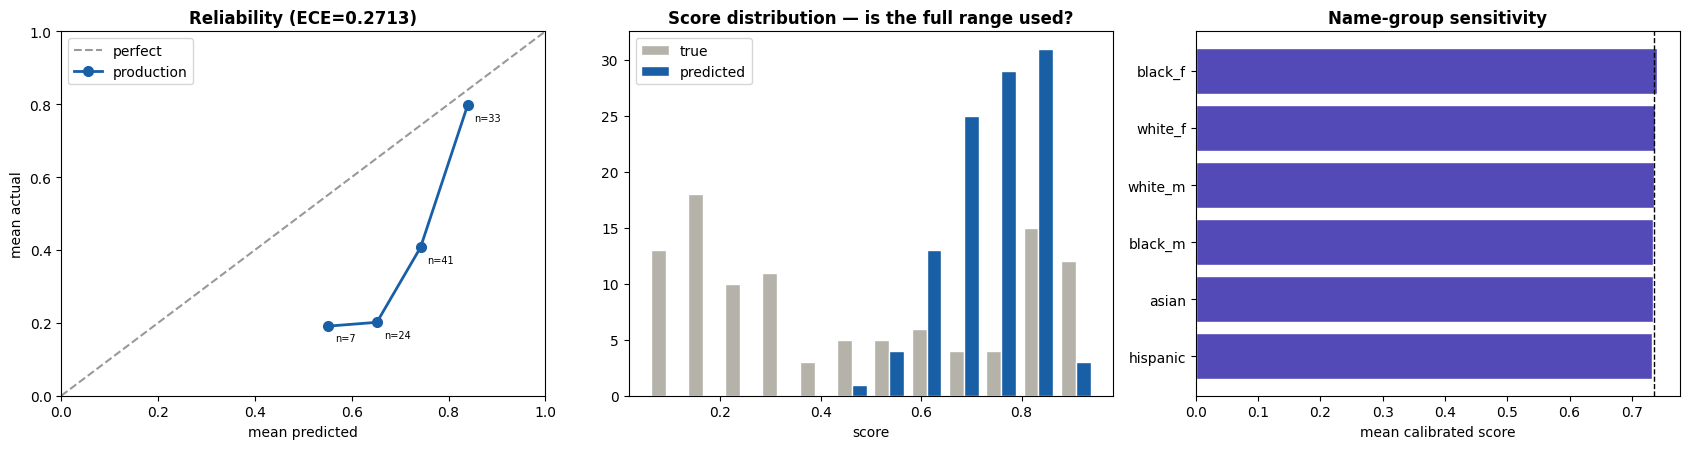

Expected Calibration Error: 0.2713
Predicted range: 0.477 - 0.878  (true: 0.054 - 0.945)


In [ ]:
# ============================================================
# CELL 6: Reliability diagram + score-range usage
# ============================================================
import matplotlib.pyplot as plt

edges = np.linspace(0, 1, 11)
idx = np.digitize(prod_pred, edges) - 1
xs, ys, ns = [], [], []
for b in range(10):
    m = idx == b
    if m.sum() >= 3:
        xs.append(prod_pred[m].mean()); ys.append(true[m].mean()); ns.append(int(m.sum()))

ece = float(np.sum([n*abs(x-y) for x, y, n in zip(xs, ys, ns)]) / max(sum(ns), 1))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].plot([0,1], [0,1], 'k--', alpha=0.4, label='perfect')
ax[0].plot(xs, ys, 'o-', color='#185FA5', lw=2, ms=7, label='production')
for x, y, n in zip(xs, ys, ns):
    ax[0].annotate(f"n={n}", (x, y), textcoords="offset points", xytext=(5, -11), fontsize=7)
ax[0].set_xlabel('mean predicted'); ax[0].set_ylabel('mean actual')
ax[0].set_title(f'Reliability (ECE={ece:.4f})', fontweight='bold'); ax[0].legend()
ax[0].set_xlim(0,1); ax[0].set_ylim(0,1)

ax[1].hist([true, prod_pred], bins=12, label=['true', 'predicted'],
           color=['#B4B2A9', '#185FA5'], edgecolor='white')
ax[1].set_title('Score distribution — is the full range used?', fontweight='bold')
ax[1].set_xlabel('score'); ax[1].legend()

gs_sorted = sorted(audit['name_bias']['groups'].items(), key=lambda kv: kv[1]['mean_score'])
ax[2].barh([g for g, _ in gs_sorted], [v['mean_score'] for _, v in gs_sorted],
           color='#534AB7', edgecolor='white')
ax[2].axvline(float(np.mean([v['mean_score'] for _, v in gs_sorted])), color='black', ls='--', lw=1)
ax[2].set_xlabel('mean calibrated score')
ax[2].set_title('Name-group sensitivity', fontweight='bold')

plt.tight_layout(); plt.savefig('model_audit.png', dpi=150, bbox_inches='tight'); plt.show()

print(f"Expected Calibration Error: {ece:.4f}")
print(f"Predicted range: {prod_pred.min():.3f} - {prod_pred.max():.3f}  (true: {true.min():.3f} - {true.max():.3f})")
audit['calibration'] = {"ece": round(ece, 4),
                        "pred_range": [round(float(prod_pred.min()), 3), round(float(prod_pred.max()), 3)],
                        "true_range": [round(float(true.min()), 3), round(float(true.max()), 3)]}

---
## 5. Failure taxonomy

"Hard negatives are hard" is not actionable. *Which* hard negatives, and how wrong, tells you
what training data to collect next — which is the entire point of error analysis.

In [ ]:
# ============================================================
# CELL 7: Where it fails, and by how much
# ============================================================
a = ext_test.copy()
a['pred'] = prod_pred
a['err']  = np.abs(a['score'].astype(float) - a['pred'])
a['signed'] = a['pred'] - a['score'].astype(float)

print("BY MATCH TYPE")
print(f"  {'type':<16} {'MAE':>7} {'bias':>8} {'n':>4}")
by_type = {}
for mt in ['strong', 'good', 'partial', 'hard_negative', 'weak']:
    s = a[a['match_type'] == mt]
    if not len(s): continue
    by_type[mt] = {"mae": round(float(s['err'].mean()), 4),
                   "bias": round(float(s['signed'].mean()), 4), "n": int(len(s))}
    print(f"  {mt:<16} {s['err'].mean():>7.4f} {s['signed'].mean():>+8.4f} {len(s):>4}")
print("\n  'bias' > 0 means the model scores this class too generously.")

if 'hard_neg_subtype' in df.columns:
    print("\n\nHARD-NEGATIVE SUBTYPES (training set — the external set lacks this column)")
    print("  Which flavour of near-miss does the model fall for?")
    sub = df[df['match_type'] == 'hard_negative'].copy()
    if len(sub):
        sub['pred'] = score_pairs(sub['resume'], sub['jd_clean'])
        sub['err'] = np.abs(sub['score'].astype(float) - sub['pred'])
        print(f"  {'subtype':<34} {'MAE':>7} {'n':>4}")
        subs = {}
        for st in sorted(sub['hard_neg_subtype'].dropna().unique()):
            s = sub[sub['hard_neg_subtype'] == st]
            subs[str(st)] = {"mae": round(float(s['err'].mean()), 4), "n": int(len(s))}
            print(f"  {str(st):<34} {s['err'].mean():>7.4f} {len(s):>4}")
        audit['hard_negative_subtypes'] = subs
        print("\n  NOTE: these pairs are from the TRAINING distribution, so treat as diagnostic")
        print("  of failure *mode*, not as a generalization estimate.")

print("\n\nWORST 5")
for _, r in a.nlargest(5, 'err').iterrows():
    print(f"  true {float(r['score']):.3f} -> pred {r['pred']:.3f} "
          f"(err {r['err']:.3f}) | {r['match_type']:<14} | {r['industry']}")

audit['by_match_type'] = by_type

BY MATCH TYPE
  type                 MAE     bias    n
  strong            0.0429  -0.0235   27
  good              0.0949  +0.0948   14
  partial           0.2804  +0.2804   13
  hard_negative     0.3993  +0.3993   26
  weak              0.5375  +0.5375   26

  'bias' > 0 means the model scores this class too generously.


HARD-NEGATIVE SUBTYPES (training set — the external set lacks this column)
  Which flavour of near-miss does the model fall for?
  subtype                                MAE    n
  impressive_irrelevant               0.3980   30
  keyword_overlap                     0.4380   22
  wrong_specialization                0.4425   19

  NOTE: these pairs are from the TRAINING distribution, so treat as diagnostic
  of failure *mode*, not as a generalization estimate.


WORST 5
  true 0.103 -> pred 0.811 (err 0.708) | weak           | Data Science / ML / AI
  true 0.054 -> pred 0.708 (err 0.654) | weak           | Healthcare / Biotech
  true 0.117 -> pred 0.753 (err 0.636) |

---
## 7. Export per-pair predictions for the demo page

The demo page shows the held-out benchmark pair by pair — every engine's prediction against
the true label, filterable by match type and industry — so a visitor can inspect the cases
the model gets wrong rather than taking an aggregate on faith.

That needs per-pair predictions, not just summary metrics. This writes them out. Claude's
predictions are merged in later from `Results/claude_benchmark_*.jsonl` by `id`, which is
why the `id` column is carried through here.

In [ ]:
# ============================================================
# CELL 9: Per-pair predictions -> demo_pairs.json
# ============================================================
export = []
for i, row in ext_test.iterrows():
    export.append({
        "id":          int(row["id"]) if "id" in row and pd.notna(row["id"]) else int(i),
        "resume":      row["resume"],
        "jd":          row["jd"],
        "jd_clean":    row["jd_clean"],
        "true":        round(float(row["score"]), 4),
        "match_type":  row["match_type"],
        "industry":    row.get("industry"),
        "jd_level":    row.get("jd_level"),
        "jd_position": row.get("jd_position"),
        "preds": {
            "finetuned_calibrated": round(float(prod_pred[i]), 4),
            "finetuned_raw":        round(float(score_pairs(
                                        [row["resume"]], [row["jd_clean"]], calibrate=False)[0]), 4),
            "base_mpnet":           round(float((be_r[i] * be_j[i]).sum()), 4),
            "tfidf":                round(float(tf_pred[i]), 4),
            "jaccard":              round(float(jac_pred[i]), 4),
        },
    })

demo = {
    "model_id": MODEL_ID,
    "n_pairs": len(export),
    "n_postings": int(ext_test["jd"].nunique()),
    "split": "external final test — 106 pairs, unseen postings, untouched by calibration",
    "metrics": {k: audit[k] for k in ("production", "base_mpnet", "tfidf", "jaccard") if k in audit},
    "calibration": audit.get("calibration"),
    "name_bias": audit.get("name_bias"),
    "preprocessing": audit.get("preprocessing"),
    "by_match_type": audit.get("by_match_type"),
    "pairs": export,
}

with open("demo_pairs.json", "w") as f:
    json.dump(demo, f, indent=1)

print(f"demo_pairs.json — {len(export)} pairs, {demo['n_postings']} postings")
print(f"  engines per pair: {list(export[0]['preds'])}")
files.download("demo_pairs.json")

demo_pairs.json — 106 pairs, 50 postings
  engines per pair: ['finetuned_calibrated', 'finetuned_raw', 'base_mpnet', 'tfidf', 'jaccard']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 8. Export the audit

In [ ]:
# ============================================================
# CELL 8: Save the audit
# ============================================================
audit['model_id'] = MODEL_ID
audit['n_final_test'] = int(len(ext_test))

with open('audit_results.json', 'w') as f:
    json.dump(audit, f, indent=2)
print(json.dumps(audit, indent=2))
files.download('audit_results.json')
files.download('model_audit.png')

{
  "tfidf": {
    "spearman": 0.5656,
    "mae": 0.4096
  },
  "jaccard": {
    "spearman": 0.5593,
    "mae": 0.4139
  },
  "base_mpnet": {
    "spearman": 0.6246,
    "mae": 0.2138
  },
  "production": {
    "spearman": 0.7891,
    "mae": 0.2876
  },
  "name_bias": {
    "groups": {
      "white_m": {
        "mean_score": 0.7356,
        "delta_vs_overall": 0.0001,
        "max_abs_shift": 0.0286
      },
      "white_f": {
        "mean_score": 0.7363,
        "delta_vs_overall": 0.0008,
        "max_abs_shift": 0.0299
      },
      "black_m": {
        "mean_score": 0.7343,
        "delta_vs_overall": -0.0012,
        "max_abs_shift": 0.028
      },
      "black_f": {
        "mean_score": 0.7402,
        "delta_vs_overall": 0.0047,
        "max_abs_shift": 0.0286
      },
      "hispanic": {
        "mean_score": 0.7326,
        "delta_vs_overall": -0.003,
        "max_abs_shift": 0.0353
      },
      "asian": {
        "mean_score": 0.734,
        "delta_vs_overall": -0.0015,

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## What this notebook can and cannot tell you

**Can:** whether the model beats a bag-of-words baseline, whether its output moves when only
a candidate's name changes, whether the preprocessing earns its complexity, and where in the
score range the calibration is weakest.

**Cannot:** whether the scores correspond to real hiring outcomes. Every label in this project
is synthetic — generated and hand-curated against a rubric. The model is faithful to that
rubric; the rubric's own fidelity to recruiter judgment is untested and is the single largest
open question in the project. See `docs/DATA_CARD.md`.

A clean bias result here means *the model is not name-sensitive on this test set with these
names*. It does not mean the system is fair to deploy in hiring. That claim needs real
outcome data, a defined use context, and review by people who are not the model's author.